In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
import joblib

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print(df.shape)
print(df.columns)
print(df.info())

(150, 6)
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [4]:
X = df.drop(["Id", "Species"], axis=1)

X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
X = df.drop("Species", axis=1)

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-1.72054204 -0.90068117  1.03205722 -1.3412724  -1.31297673]
 [-1.69744751 -1.14301691 -0.1249576  -1.3412724  -1.31297673]
 [-1.67435299 -1.38535265  0.33784833 -1.39813811 -1.31297673]
 [-1.65125846 -1.50652052  0.10644536 -1.2844067  -1.31297673]
 [-1.62816394 -1.02184904  1.26346019 -1.3412724  -1.31297673]]


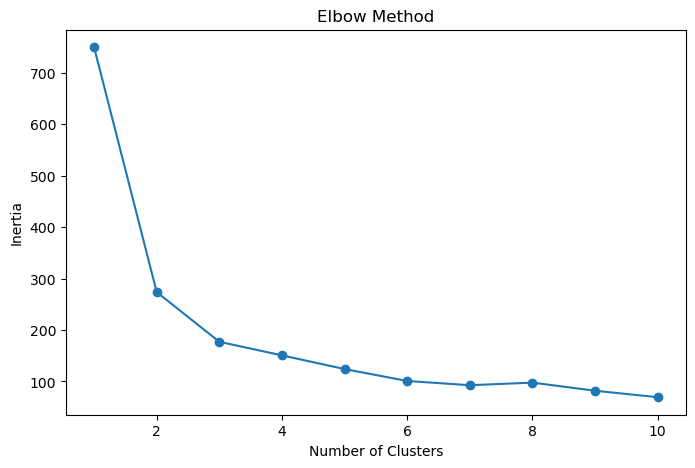

In [9]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,2
1,2,4.9,3.0,1.4,0.2,Iris-setosa,2
2,3,4.7,3.2,1.3,0.2,Iris-setosa,2
3,4,4.6,3.1,1.5,0.2,Iris-setosa,2
4,5,5.0,3.6,1.4,0.2,Iris-setosa,2


In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(150, 2)


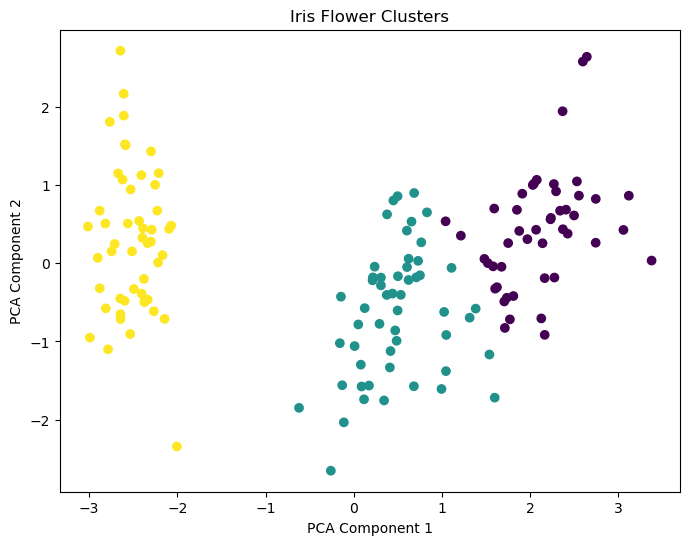

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Iris Flower Clusters")

plt.show()

In [13]:
species_mapping = {
    "Iris-setosa":0,
    "Iris-versicolor":1,
    "Iris-virginica":2
}

y_true = df["Species"].map(species_mapping)

print(y_true.head())

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64


In [14]:
cm = confusion_matrix(
    y_true,
    clusters
)

print(cm)

[[ 0  0 50]
 [ 2 48  0]
 [45  5  0]]


In [15]:
joblib.dump(
    kmeans,
    "iris_kmeans_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [16]:
loaded_model = joblib.load(
    "iris_kmeans_model.pkl"
)

print(loaded_model)

KMeans(n_clusters=3, random_state=42)


In [17]:
pip install pandas numpy matplotlib scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.
